# EDA: impacto del mal tiempo en retrasos de vuelos

Este notebook realiza una mini EDA sobre `M1_final.csv` para estudiar si las condiciones meteorológicas adversas se asocian con mayores retrasos de vuelos.

El objetivo operativo es extraer métricas simples que puedan alimentar un sistema de recomendaciones de flujo de pasajeros en aeropuerto, evitando saturar la zona de embarque cuando el mal tiempo incrementa el tiempo de permanencia de los pasajeros.

## 1. Configuración y carga de datos

Primero se cargan las librerías y el CSV. La detección de columnas se hace de forma robusta tras normalizar nombres a minúsculas y `snake_case`.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    plt = None
    MATPLOTLIB_AVAILABLE = False

try:
    import seaborn as sns
    SEABORN_AVAILABLE = MATPLOTLIB_AVAILABLE
    if MATPLOTLIB_AVAILABLE:
        sns.set_theme(style="whitegrid", palette="Set2")
except ImportError:
    SEABORN_AVAILABLE = False

warnings.filterwarnings("ignore")

DATA_DIR = Path(".")
CSV_PATH = DATA_DIR / "M1_final.csv"
OUTPUT_METRICS_PATH = DATA_DIR / "eda_operational_metrics.csv"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print(f"CSV encontrado: {CSV_PATH.resolve()}")
df_raw = pd.read_csv(CSV_PATH)
df_raw.head()

CSV encontrado: C:\Users\User\Desktop\club proyecto\tiempo_atmosférico\M1_final.csv


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,DEP_TIME_M,CRS_ARR_M,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,323,448,48,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,333,531,48,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,341,482,48,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,343,513,48,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,356,499,46,32,58,W,24,35,29.91,Fair / Windy,9,17,13


## A) Exploración inicial

Antes de transformar columnas, se revisan tamaño, nombres originales, tipos, primeras filas, nulos y estadísticas descriptivas.

In [2]:
print("Tamaño del dataset (filas, columnas):", df_raw.shape)
print("\nColumnas originales:")
display(pd.DataFrame({"column": df_raw.columns}))

print("\nTipos de datos:")
display(df_raw.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

print("\nPrimeras filas:")
display(df_raw.head())

null_pct_raw = (
    df_raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("null_percentage")
    .reset_index()
    .rename(columns={"index": "column"})
)
print("\nPorcentaje de valores nulos por columna:")
display(null_pct_raw)

print("\nNúmero de vuelos totales:", len(df_raw))

print("\nEstadísticas descriptivas de columnas numéricas:")
display(df_raw.describe(include=[np.number]).T)

Tamaño del dataset (filas, columnas): (28820, 23)

Columnas originales:


,column
0,MONTH
1,DAY_OF_MONTH
2,DAY_OF_WEEK
3,OP_UNIQUE_CARRIER
4,TAIL_NUM
5,DEST
6,DEP_DELAY
7,CRS_ELAPSED_TIME
8,DISTANCE
9,CRS_DEP_M



Tipos de datos:


,column,dtype
0,MONTH,int64
1,DAY_OF_MONTH,int64
2,DAY_OF_WEEK,int64
3,OP_UNIQUE_CARRIER,str
4,TAIL_NUM,str
5,DEST,str
6,DEP_DELAY,int64
7,CRS_ELAPSED_TIME,int64
8,DISTANCE,int64
9,CRS_DEP_M,int64



Primeras filas:


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,DEP_TIME_M,CRS_ARR_M,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,323,448,48,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,333,531,48,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,341,482,48,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,343,513,48,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,356,499,46,32,58,W,24,35,29.91,Fair / Windy,9,17,13



Porcentaje de valores nulos por columna:


,column,null_percentage
0,Wind,0.01
1,DAY_OF_MONTH,0.00
2,MONTH,0.00
3,OP_UNIQUE_CARRIER,0.00
4,TAIL_NUM,0.00
5,DEST,0.00
6,DAY_OF_WEEK,0.00
7,DEP_DELAY,0.00
8,CRS_ELAPSED_TIME,0.00
9,CRS_DEP_M,0.00



Número de vuelos totales: 28820

Estadísticas descriptivas de columnas numéricas:


,count,mean,std,min,25%,50%,75%,max
MONTH,"28,820.00",7.89,4.99,1.00,1.00,11.00,12.00,12.00
DAY_OF_MONTH,"28,820.00",16.02,8.75,1.00,8.00,16.00,24.00,31.00
DAY_OF_WEEK,"28,820.00",4.01,1.99,1.00,2.00,4.00,6.00,7.00
DEP_DELAY,"28,820.00",6.37,38.74,-22.00,-6.00,-3.00,2.00,"1,276.00"
CRS_ELAPSED_TIME,"28,820.00",225.29,119.48,57.00,124.00,188.00,365.00,697.00
DISTANCE,"28,820.00","1,267.75",889.34,94.00,483.00,"1,029.00","2,248.00","4,983.00"
CRS_DEP_M,"28,820.00",831.00,299.40,301.00,545.00,856.00,"1,095.00","1,439.00"
DEP_TIME_M,"28,820.00",828.93,305.86,1.00,542.00,854.00,"1,097.00","1,440.00"
CRS_ARR_M,"28,820.00",910.87,345.41,1.00,667.00,918.00,"1,193.00","1,439.00"
Temperature,"28,820.00",41.49,8.04,17.00,36.00,42.00,47.00,68.00


## B) Limpieza mínima y detección automática de columnas

Se normalizan nombres, se detectan columnas relevantes y se crean variables binarias cuando la información existe.

In [3]:
def normalize_column_name(name):
    # Convierte nombres de columnas a minúsculas y snake_case.
    name = str(name).strip().lower()
    replacements = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u", "ü": "u", "ñ": "n"
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def find_first_column(columns, include_any=None, include_all=None, exclude_any=None):
    # Busca la primera columna cuyo nombre cumple patrones flexibles.
    include_any = include_any or []
    include_all = include_all or []
    exclude_any = exclude_any or []
    for col in columns:
        col_l = col.lower()
        if include_any and not any(pattern in col_l for pattern in include_any):
            continue
        if include_all and not all(pattern in col_l for pattern in include_all):
            continue
        if exclude_any and any(pattern in col_l for pattern in exclude_any):
            continue
        return col
    return None


def warn_missing(label, column):
    if column is None:
        print(f"AVISO: no se encontró una columna clara para '{label}'. Se continuará con los análisis posibles.")


df = df_raw.copy()
df.columns = [normalize_column_name(c) for c in df.columns]

print("Columnas normalizadas:")
display(pd.DataFrame({"column": df.columns}))

columns = list(df.columns)

departure_delay_col = find_first_column(
    columns,
    include_any=["dep_delay", "departure_delay", "delay_departure", "salida_retraso", "retraso_salida"],
    exclude_any=["weather", "arr", "arrival"],
)
arrival_delay_col = find_first_column(
    columns,
    include_any=["arr_delay", "arrival_delay", "delay_arrival", "llegada_retraso", "retraso_llegada"],
    exclude_any=["weather", "dep", "departure"],
)
weather_delay_col = find_first_column(
    columns,
    include_all=["weather", "delay"],
) or find_first_column(
    columns,
    include_any=["retraso_meteorologico", "weather_delay", "meteo_delay"]
)
cancellation_col = find_first_column(
    columns,
    include_any=["cancelled", "canceled", "cancelacion", "cancelado", "cancelled_flight"],
)
date_col = find_first_column(
    columns,
    include_any=["flight_date", "date", "fecha"],
)
departure_time_col = find_first_column(
    columns,
    include_any=["dep_time", "crs_dep_time", "departure_time", "hora_salida", "dep_time_m", "crs_dep_m"],
)
origin_col = find_first_column(
    columns,
    include_any=["origin", "origen", "origin_airport", "aeropuerto_origen"],
)
destination_col = find_first_column(
    columns,
    include_any=["dest", "destination", "destino", "dest_airport", "aeropuerto_destino"],
)
condition_col = find_first_column(
    columns,
    include_any=["condition", "conditions", "weather_condition", "weather_conditions", "condicion", "condiciones"],
)

weather_feature_cols = [
    c for c in columns
    if any(token in c for token in ["temperature", "dew", "humidity", "wind", "pressure", "condition", "weather", "visibility", "precip"])
]

detected_columns = pd.DataFrame(
    {
        "semantic_field": [
            "departure_delay", "arrival_delay", "weather_delay", "cancellation",
            "date", "departure_time", "origin_airport", "destination_airport",
            "weather_condition",
        ],
        "detected_column": [
            departure_delay_col, arrival_delay_col, weather_delay_col, cancellation_col,
            date_col, departure_time_col, origin_col, destination_col, condition_col,
        ],
    }
)
display(detected_columns)

print("Columnas meteorológicas detectadas:", weather_feature_cols)

for label, col in [
    ("retraso de salida", departure_delay_col),
    ("retraso de llegada", arrival_delay_col),
    ("retraso meteorológico", weather_delay_col),
    ("cancelaciones", cancellation_col),
    ("fecha", date_col),
    ("hora de salida", departure_time_col),
]:
    warn_missing(label, col)

Columnas normalizadas:


,column
0,month
1,day_of_month
2,day_of_week
3,op_unique_carrier
4,tail_num
5,dest
6,dep_delay
7,crs_elapsed_time
8,distance
9,crs_dep_m


,semantic_field,detected_column
0,departure_delay,dep_delay
1,arrival_delay,NaN
2,weather_delay,NaN
3,cancellation,NaN
4,date,NaN
5,departure_time,crs_dep_m
6,origin_airport,NaN
7,destination_airport,dest
8,weather_condition,condition


Columnas meteorológicas detectadas: ['temperature', 'dew_point', 'humidity', 'wind', 'wind_speed', 'wind_gust', 'pressure', 'condition']
AVISO: no se encontró una columna clara para 'retraso de llegada'. Se continuará con los análisis posibles.
AVISO: no se encontró una columna clara para 'retraso meteorológico'. Se continuará con los análisis posibles.
AVISO: no se encontró una columna clara para 'cancelaciones'. Se continuará con los análisis posibles.
AVISO: no se encontró una columna clara para 'fecha'. Se continuará con los análisis posibles.


In [4]:
# Conversión segura de columnas numéricas clave
for col in [departure_delay_col, arrival_delay_col, weather_delay_col, cancellation_col, departure_time_col]:
    if col is not None and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Conversión de fecha si existe una columna directa.
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
elif {"year", "month", "day_of_month"}.issubset(df.columns):
    df["flight_date_inferred"] = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=df["day_of_month"]),
        errors="coerce",
    )
    date_col = "flight_date_inferred"
elif {"month", "day_of_month"}.issubset(df.columns):
    # El dataset no siempre incluye año; se usa un año ficticio estable para habilitar agregaciones por fecha.
    df["flight_date_inferred"] = pd.to_datetime(
        dict(year=2020, month=df["month"], day=df["day_of_month"]),
        errors="coerce",
    )
    date_col = "flight_date_inferred"
    print("AVISO: se creó 'flight_date_inferred' usando año ficticio 2020 porque no había columna de año.")

# Hora de salida: muchos datasets codifican minutos desde medianoche en columnas *_m.
if departure_time_col is not None:
    dep_time = pd.to_numeric(df[departure_time_col], errors="coerce")
    if departure_time_col.endswith("_m") or dep_time.dropna().between(0, 1440).mean() > 0.90:
        df["departure_hour"] = (dep_time // 60).astype("float").clip(0, 23)
    else:
        dep_as_text = df[departure_time_col].astype("Int64").astype(str).str.zfill(4)
        df["departure_hour"] = pd.to_numeric(dep_as_text.str[:2], errors="coerce").clip(0, 23)
else:
    df["departure_hour"] = np.nan

# Variables binarias de retraso
if departure_delay_col is not None:
    df["delayed_departure_15"] = df[departure_delay_col] >= 15
else:
    df["delayed_departure_15"] = np.nan

if arrival_delay_col is not None:
    df["delayed_arrival_15"] = df[arrival_delay_col] >= 15
else:
    df["delayed_arrival_15"] = np.nan

# Variable binaria de mal tiempo
bad_weather_keywords = [
    "rain", "drizzle", "snow", "sleet", "hail", "thunder", "storm", "fog",
    "mist", "haze", "smoke", "windy", "blowing", "freezing", "ice",
    "lluvia", "nieve", "tormenta", "niebla", "viento", "granizo"
]

if weather_delay_col is not None:
    df["bad_weather_flight"] = pd.to_numeric(df[weather_delay_col], errors="coerce").fillna(0) > 0
    bad_weather_source = f"{weather_delay_col} > 0"
elif condition_col is not None:
    condition_text = df[condition_col].astype(str).str.lower()
    df["bad_weather_flight"] = condition_text.apply(lambda value: any(keyword in value for keyword in bad_weather_keywords))
    bad_weather_source = f"palabras meteorológicas adversas en {condition_col}"
else:
    df["bad_weather_flight"] = False
    bad_weather_source = "no disponible; se asignó False para no romper el análisis"
    print("AVISO: no se encontró columna de retraso meteorológico ni condiciones. 'bad_weather_flight' queda en False.")

print("Fuente usada para bad_weather_flight:", bad_weather_source)
display(df[["bad_weather_flight", "delayed_departure_15", "delayed_arrival_15"]].head())

AVISO: se creó 'flight_date_inferred' usando año ficticio 2020 porque no había columna de año.
Fuente usada para bad_weather_flight: palabras meteorológicas adversas en condition


,bad_weather_flight,delayed_departure_15,delayed_arrival_15
0,True,False,NaN
1,True,False,NaN
2,True,True,NaN
3,True,False,NaN
4,True,False,NaN


In [5]:
print("Número de vuelos totales:", len(df))

if cancellation_col is not None:
    cancelled_flights = pd.to_numeric(df[cancellation_col], errors="coerce").fillna(0).astype(bool).sum()
    print("Número de vuelos cancelados:", int(cancelled_flights))
else:
    print("Número de vuelos cancelados: no disponible")

print("\nEstadísticas descriptivas tras limpieza mínima:")
display(df.describe(include=[np.number]).T)

Número de vuelos totales: 28820
Número de vuelos cancelados: no disponible

Estadísticas descriptivas tras limpieza mínima:


,count,mean,std,min,25%,50%,75%,max
month,"28,820.00",7.89,4.99,1.00,1.00,11.00,12.00,12.00
day_of_month,"28,820.00",16.02,8.75,1.00,8.00,16.00,24.00,31.00
day_of_week,"28,820.00",4.01,1.99,1.00,2.00,4.00,6.00,7.00
dep_delay,"28,820.00",6.37,38.74,-22.00,-6.00,-3.00,2.00,"1,276.00"
crs_elapsed_time,"28,820.00",225.29,119.48,57.00,124.00,188.00,365.00,697.00
distance,"28,820.00","1,267.75",889.34,94.00,483.00,"1,029.00","2,248.00","4,983.00"
crs_dep_m,"28,820.00",831.00,299.40,301.00,545.00,856.00,"1,095.00","1,439.00"
dep_time_m,"28,820.00",828.93,305.86,1.00,542.00,854.00,"1,097.00","1,440.00"
crs_arr_m,"28,820.00",910.87,345.41,1.00,667.00,918.00,"1,193.00","1,439.00"
temperature,"28,820.00",41.49,8.04,17.00,36.00,42.00,47.00,68.00


## C) Comparación: mal tiempo vs no mal tiempo

Se comparan retrasos y tasas de retraso de 15 minutos o más entre vuelos con y sin indicio de mal tiempo.

In [6]:
def safe_mean(series):
    return pd.to_numeric(series, errors="coerce").mean() if series is not None else np.nan


def safe_median(series):
    return pd.to_numeric(series, errors="coerce").median() if series is not None else np.nan


def safe_quantile(series, q):
    return pd.to_numeric(series, errors="coerce").quantile(q) if series is not None else np.nan


def safe_percentage_true(series):
    if series is None:
        return np.nan
    valid = series.dropna()
    if len(valid) == 0:
        return np.nan
    return valid.astype(bool).mean() * 100


def safe_ratio(numerator, denominator):
    if pd.isna(numerator) or pd.isna(denominator) or denominator == 0:
        return np.nan
    return numerator / denominator


def group_series(col, bad_weather=True):
    if col is None or col not in df.columns:
        return None
    return df.loc[df["bad_weather_flight"].eq(bad_weather), col]


bad_weather_flights = int(df["bad_weather_flight"].sum())
normal_weather_flights = int((~df["bad_weather_flight"]).sum())

comparison_rows = []

for label, col, delay_15_col in [
    ("departure", departure_delay_col, "delayed_departure_15"),
    ("arrival", arrival_delay_col, "delayed_arrival_15"),
]:
    bad = group_series(col, True)
    normal = group_series(col, False)
    delayed_bad = df.loc[df["bad_weather_flight"].eq(True), delay_15_col] if delay_15_col in df.columns else None
    delayed_normal = df.loc[df["bad_weather_flight"].eq(False), delay_15_col] if delay_15_col in df.columns else None

    comparison_rows.extend(
        [
            {"metric": f"avg_{label}_delay_bad_weather", "value": safe_mean(bad)},
            {"metric": f"avg_{label}_delay_normal_weather", "value": safe_mean(normal)},
            {"metric": f"median_{label}_delay_bad_weather", "value": safe_median(bad)},
            {"metric": f"median_{label}_delay_normal_weather", "value": safe_median(normal)},
            {"metric": f"p75_{label}_delay_bad_weather", "value": safe_quantile(bad, 0.75)},
            {"metric": f"p75_{label}_delay_normal_weather", "value": safe_quantile(normal, 0.75)},
            {"metric": f"p90_{label}_delay_bad_weather", "value": safe_quantile(bad, 0.90)},
            {"metric": f"p90_{label}_delay_normal_weather", "value": safe_quantile(normal, 0.90)},
            {"metric": f"delayed_15_percentage_{label}_bad_weather", "value": safe_percentage_true(delayed_bad)},
            {"metric": f"delayed_15_percentage_{label}_normal_weather", "value": safe_percentage_true(delayed_normal)},
        ]
    )

comparison = pd.DataFrame(comparison_rows)

avg_dep_bad = comparison.loc[comparison["metric"].eq("avg_departure_delay_bad_weather"), "value"].squeeze()
avg_dep_normal = comparison.loc[comparison["metric"].eq("avg_departure_delay_normal_weather"), "value"].squeeze()

extra_rows = pd.DataFrame(
    [
        {"metric": "bad_weather_flights", "value": bad_weather_flights},
        {"metric": "normal_weather_flights", "value": normal_weather_flights},
        {"metric": "absolute_avg_departure_delay_difference", "value": avg_dep_bad - avg_dep_normal if pd.notna(avg_dep_bad) and pd.notna(avg_dep_normal) else np.nan},
        {"metric": "weather_delay_multiplier", "value": safe_ratio(avg_dep_bad, avg_dep_normal)},
    ]
)

comparison = pd.concat([extra_rows, comparison], ignore_index=True)
display(comparison)

,metric,value
0,bad_weather_flights,"6,374.00"
1,normal_weather_flights,"22,446.00"
2,absolute_avg_departure_delay_difference,4.91
3,weather_delay_multiplier,1.93
4,avg_departure_delay_bad_weather,10.20
5,avg_departure_delay_normal_weather,5.29
6,median_departure_delay_bad_weather,-2.00
7,median_departure_delay_normal_weather,-3.00
8,p75_departure_delay_bad_weather,6.00
9,p75_departure_delay_normal_weather,1.00


## D) Distribuciones y gráficos

Los gráficos se generan solo cuando existen las columnas necesarias. Si falta alguna columna, se muestra un aviso y el notebook continúa.

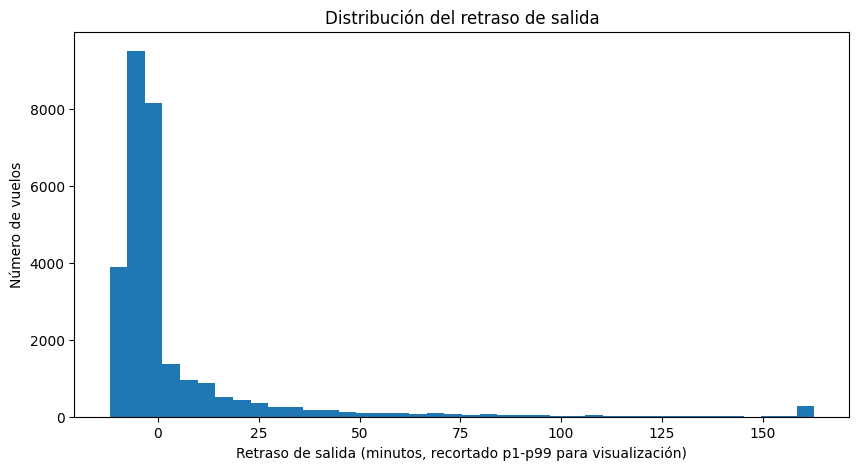

<Figure size 800x500 with 0 Axes>

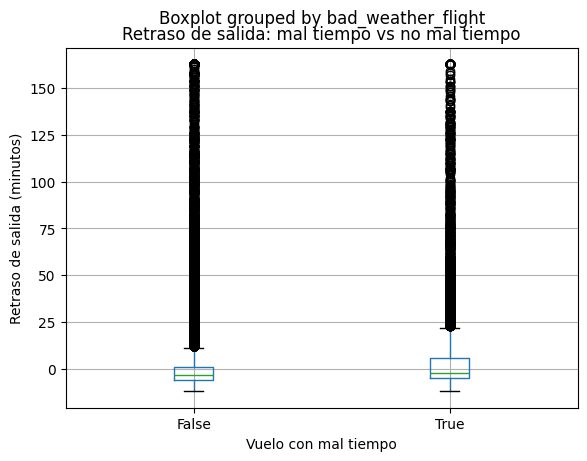

AVISO: no existe matplotlib o columna explícita de retraso meteorológico para histograma.


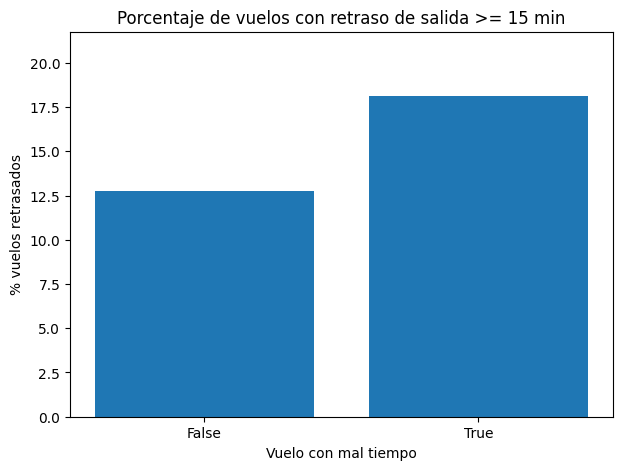

In [7]:
def plot_or_warn(condition, message):
    if not condition:
        print(f"AVISO: {message}")
    return condition


def clip_for_plot(series, lower=0.01, upper=0.99):
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return numeric
    lo, hi = numeric.quantile([lower, upper])
    return numeric.clip(lo, hi)


if plot_or_warn(MATPLOTLIB_AVAILABLE and departure_delay_col is not None, "no se puede graficar retraso de salida porque falta matplotlib o la columna."):
    plt.figure(figsize=(10, 5))
    plot_data = clip_for_plot(df[departure_delay_col])
    if SEABORN_AVAILABLE:
        sns.histplot(plot_data, bins=40, kde=True)
    else:
        plt.hist(plot_data, bins=40)
    plt.title("Distribución del retraso de salida")
    plt.xlabel("Retraso de salida (minutos, recortado p1-p99 para visualización)")
    plt.ylabel("Número de vuelos")
    plt.show()


if plot_or_warn(MATPLOTLIB_AVAILABLE and departure_delay_col is not None and "bad_weather_flight" in df.columns, "no se puede crear boxplot mal tiempo vs normal."):
    plt.figure(figsize=(8, 5))
    plot_df = df[[departure_delay_col, "bad_weather_flight"]].copy()
    plot_df[departure_delay_col] = clip_for_plot(plot_df[departure_delay_col])
    if SEABORN_AVAILABLE:
        sns.boxplot(data=plot_df, x="bad_weather_flight", y=departure_delay_col)
    else:
        plot_df.boxplot(column=departure_delay_col, by="bad_weather_flight")
    plt.title("Retraso de salida: mal tiempo vs no mal tiempo")
    plt.xlabel("Vuelo con mal tiempo")
    plt.ylabel("Retraso de salida (minutos)")
    plt.show()


if plot_or_warn(MATPLOTLIB_AVAILABLE and weather_delay_col is not None, "no existe matplotlib o columna explícita de retraso meteorológico para histograma."):
    plt.figure(figsize=(10, 5))
    weather_delay_plot = clip_for_plot(df[weather_delay_col])
    if SEABORN_AVAILABLE:
        sns.histplot(weather_delay_plot, bins=40, kde=True)
    else:
        plt.hist(weather_delay_plot, bins=40)
    plt.title("Distribución del retraso meteorológico")
    plt.xlabel("Retraso meteorológico (minutos)")
    plt.ylabel("Número de vuelos")
    plt.show()


if plot_or_warn(MATPLOTLIB_AVAILABLE and "delayed_departure_15" in df.columns and df["delayed_departure_15"].notna().any(), "no se puede graficar porcentaje de retrasos >=15 min."):
    delayed_pct_by_weather = (
        df.groupby("bad_weather_flight")["delayed_departure_15"]
        .mean()
        .mul(100)
        .reset_index(name="delayed_15_percentage")
    )
    plt.figure(figsize=(7, 5))
    if SEABORN_AVAILABLE:
        sns.barplot(data=delayed_pct_by_weather, x="bad_weather_flight", y="delayed_15_percentage")
    else:
        plt.bar(delayed_pct_by_weather["bad_weather_flight"].astype(str), delayed_pct_by_weather["delayed_15_percentage"])
    plt.title("Porcentaje de vuelos con retraso de salida >= 15 min")
    plt.xlabel("Vuelo con mal tiempo")
    plt.ylabel("% vuelos retrasados")
    plt.ylim(0, max(5, delayed_pct_by_weather["delayed_15_percentage"].max() * 1.2))
    plt.show()

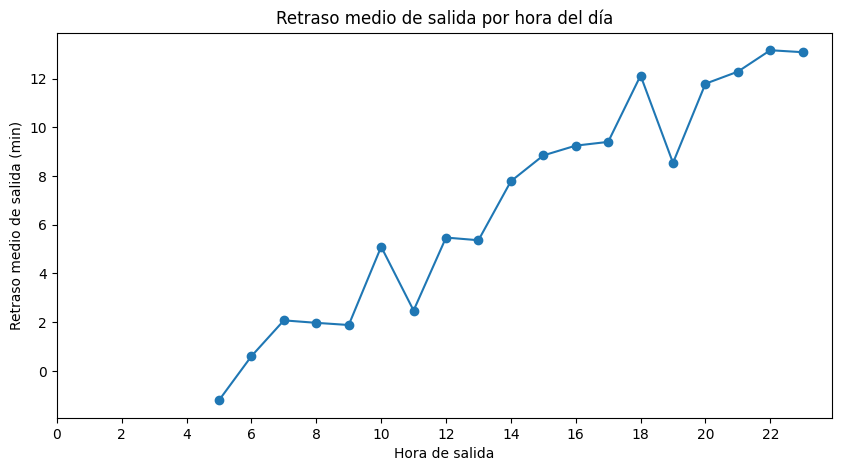

,dest,avg_departure_delay,flights
0,PSE,23.36,78
1,ORH,16.21,90
2,BWI,15.67,383
3,SAT,15.33,160
4,IAH,11.95,256
5,SMF,11.29,82
6,ORD,11.07,610
7,MSP,10.68,328
8,BOS,10.54,1243
9,BTV,10.34,481


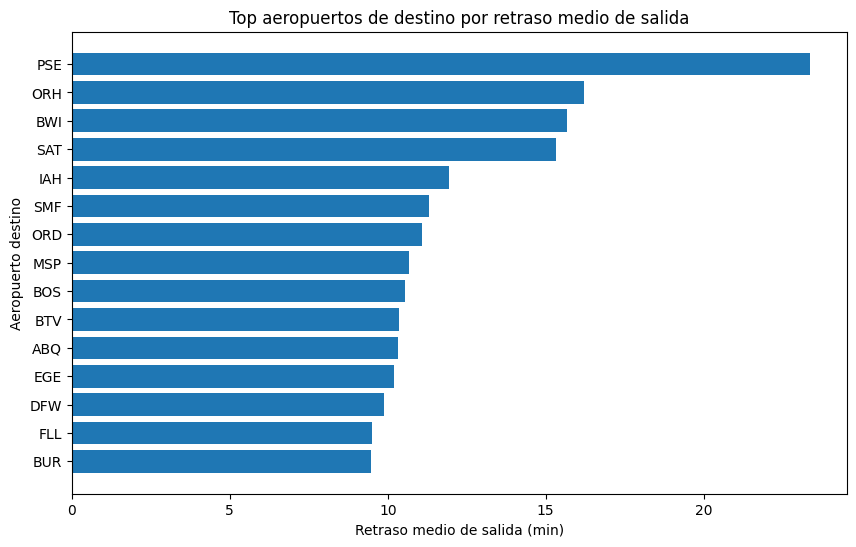

AVISO: no hay matplotlib o columna de cancelaciones para comparar porcentajes.


In [8]:
if plot_or_warn(MATPLOTLIB_AVAILABLE and departure_delay_col is not None and df["departure_hour"].notna().any(), "no hay matplotlib u hora de salida utilizable para retraso medio por hora."):
    delay_by_hour = (
        df.dropna(subset=["departure_hour"])
        .groupby("departure_hour")[departure_delay_col]
        .mean()
        .reset_index()
    )
    plt.figure(figsize=(10, 5))
    if SEABORN_AVAILABLE:
        sns.lineplot(data=delay_by_hour, x="departure_hour", y=departure_delay_col, marker="o")
    else:
        plt.plot(delay_by_hour["departure_hour"], delay_by_hour[departure_delay_col], marker="o")
    plt.title("Retraso medio de salida por hora del día")
    plt.xlabel("Hora de salida")
    plt.ylabel("Retraso medio de salida (min)")
    plt.xticks(range(0, 24, 2))
    plt.show()


airport_col = origin_col or destination_col
airport_label = "origen" if origin_col is not None else "destino"

if plot_or_warn(MATPLOTLIB_AVAILABLE and departure_delay_col is not None and airport_col is not None, "no hay matplotlib o aeropuerto origen/destino para ranking."):
    airport_delay = (
        df.groupby(airport_col)
        .agg(
            avg_departure_delay=(departure_delay_col, "mean"),
            flights=(departure_delay_col, "size"),
        )
        .query("flights >= 10")
        .sort_values("avg_departure_delay", ascending=False)
        .head(15)
        .reset_index()
    )
    display(airport_delay)
    plt.figure(figsize=(10, 6))
    if SEABORN_AVAILABLE:
        sns.barplot(data=airport_delay, y=airport_col, x="avg_departure_delay", orient="h")
    else:
        plt.barh(airport_delay[airport_col].astype(str), airport_delay["avg_departure_delay"])
    plt.title(f"Top aeropuertos de {airport_label} por retraso medio de salida")
    plt.xlabel("Retraso medio de salida (min)")
    plt.ylabel(f"Aeropuerto {airport_label}")
    plt.gca().invert_yaxis()
    plt.show()


if plot_or_warn(MATPLOTLIB_AVAILABLE and cancellation_col is not None, "no hay matplotlib o columna de cancelaciones para comparar porcentajes."):
    cancel_pct = (
        df.assign(cancelled_flag=pd.to_numeric(df[cancellation_col], errors="coerce").fillna(0).astype(bool))
        .groupby("bad_weather_flight")["cancelled_flag"]
        .mean()
        .mul(100)
        .reset_index(name="cancellation_percentage")
    )
    display(cancel_pct)
    plt.figure(figsize=(7, 5))
    if SEABORN_AVAILABLE:
        sns.barplot(data=cancel_pct, x="bad_weather_flight", y="cancellation_percentage")
    else:
        plt.bar(cancel_pct["bad_weather_flight"].astype(str), cancel_pct["cancellation_percentage"])
    plt.title("Porcentaje de cancelación: mal tiempo vs no mal tiempo")
    plt.xlabel("Vuelo con mal tiempo")
    plt.ylabel("% cancelaciones")
    plt.show()

## E) Métricas útiles para el sistema de recomendaciones

La tabla `operational_metrics` resume señales accionables para el dashboard.

La métrica `recommended_extra_boarding_buffer_minutes` se estima como la diferencia positiva entre la mediana de retraso de salida con mal tiempo y sin mal tiempo. Si no hay medianas disponibles, se usa la diferencia de medias. Se redondea hacia arriba porque, operativamente, es preferible reservar margen adicional cuando el riesgo meteorológico aumenta.

La métrica `weather_delay_multiplier` divide el retraso medio con mal tiempo entre el retraso medio sin mal tiempo, evitando división por cero.

In [9]:
def value_or_nan(value):
    return value if pd.notna(value) else np.nan


def metric_from_comparison(metric_name):
    values = comparison.loc[comparison["metric"].eq(metric_name), "value"]
    if values.empty:
        return np.nan
    return values.iloc[0]


total_flights = len(df)
bad_weather_flight_percentage = (bad_weather_flights / total_flights * 100) if total_flights else np.nan

avg_departure_delay_bad_weather = metric_from_comparison("avg_departure_delay_bad_weather")
avg_departure_delay_normal_weather = metric_from_comparison("avg_departure_delay_normal_weather")
median_departure_delay_bad_weather = metric_from_comparison("median_departure_delay_bad_weather")
median_departure_delay_normal_weather = metric_from_comparison("median_departure_delay_normal_weather")
p75_departure_delay_bad_weather = metric_from_comparison("p75_departure_delay_bad_weather")
p75_departure_delay_normal_weather = metric_from_comparison("p75_departure_delay_normal_weather")
p90_departure_delay_bad_weather = metric_from_comparison("p90_departure_delay_bad_weather")
p90_departure_delay_normal_weather = metric_from_comparison("p90_departure_delay_normal_weather")
delayed_15_percentage_bad_weather = metric_from_comparison("delayed_15_percentage_departure_bad_weather")
delayed_15_percentage_normal_weather = metric_from_comparison("delayed_15_percentage_departure_normal_weather")
avg_arrival_delay_bad_weather = metric_from_comparison("avg_arrival_delay_bad_weather")
avg_arrival_delay_normal_weather = metric_from_comparison("avg_arrival_delay_normal_weather")

if cancellation_col is not None:
    cancelled_flag = pd.to_numeric(df[cancellation_col], errors="coerce").fillna(0).astype(bool)
    cancellation_percentage_bad_weather = cancelled_flag[df["bad_weather_flight"]].mean() * 100 if bad_weather_flights else np.nan
    cancellation_percentage_normal_weather = cancelled_flag[~df["bad_weather_flight"]].mean() * 100 if normal_weather_flights else np.nan
else:
    cancellation_percentage_bad_weather = np.nan
    cancellation_percentage_normal_weather = np.nan

median_diff = (
    median_departure_delay_bad_weather - median_departure_delay_normal_weather
    if pd.notna(median_departure_delay_bad_weather) and pd.notna(median_departure_delay_normal_weather)
    else np.nan
)
mean_diff = (
    avg_departure_delay_bad_weather - avg_departure_delay_normal_weather
    if pd.notna(avg_departure_delay_bad_weather) and pd.notna(avg_departure_delay_normal_weather)
    else np.nan
)

buffer_basis = median_diff if pd.notna(median_diff) else mean_diff
recommended_extra_boarding_buffer_minutes = max(0, float(np.ceil(buffer_basis))) if pd.notna(buffer_basis) else np.nan

weather_delay_multiplier = safe_ratio(avg_departure_delay_bad_weather, avg_departure_delay_normal_weather)

if pd.isna(recommended_extra_boarding_buffer_minutes) and pd.isna(weather_delay_multiplier):
    boarding_saturation_risk_comment = "Insufficient data"
elif (pd.notna(weather_delay_multiplier) and weather_delay_multiplier >= 1.5) or (
    pd.notna(recommended_extra_boarding_buffer_minutes) and recommended_extra_boarding_buffer_minutes > 20
):
    boarding_saturation_risk_comment = "High risk"
elif (pd.notna(weather_delay_multiplier) and weather_delay_multiplier >= 1.15) or (
    pd.notna(recommended_extra_boarding_buffer_minutes) and recommended_extra_boarding_buffer_minutes >= 10
):
    boarding_saturation_risk_comment = "Moderate risk"
else:
    boarding_saturation_risk_comment = "Low risk"

operational_metrics = pd.DataFrame(
    [
        {"metric": "total_flights", "value": total_flights},
        {"metric": "bad_weather_flights", "value": bad_weather_flights},
        {"metric": "bad_weather_flight_percentage", "value": bad_weather_flight_percentage},
        {"metric": "avg_departure_delay_bad_weather", "value": avg_departure_delay_bad_weather},
        {"metric": "avg_departure_delay_normal_weather", "value": avg_departure_delay_normal_weather},
        {"metric": "median_departure_delay_bad_weather", "value": median_departure_delay_bad_weather},
        {"metric": "median_departure_delay_normal_weather", "value": median_departure_delay_normal_weather},
        {"metric": "p75_departure_delay_bad_weather", "value": p75_departure_delay_bad_weather},
        {"metric": "p75_departure_delay_normal_weather", "value": p75_departure_delay_normal_weather},
        {"metric": "p90_departure_delay_bad_weather", "value": p90_departure_delay_bad_weather},
        {"metric": "p90_departure_delay_normal_weather", "value": p90_departure_delay_normal_weather},
        {"metric": "delayed_15_percentage_bad_weather", "value": delayed_15_percentage_bad_weather},
        {"metric": "delayed_15_percentage_normal_weather", "value": delayed_15_percentage_normal_weather},
        {"metric": "avg_arrival_delay_bad_weather", "value": avg_arrival_delay_bad_weather},
        {"metric": "avg_arrival_delay_normal_weather", "value": avg_arrival_delay_normal_weather},
        {"metric": "cancellation_percentage_bad_weather", "value": cancellation_percentage_bad_weather},
        {"metric": "cancellation_percentage_normal_weather", "value": cancellation_percentage_normal_weather},
        {"metric": "recommended_extra_boarding_buffer_minutes", "value": recommended_extra_boarding_buffer_minutes},
        {"metric": "weather_delay_multiplier", "value": weather_delay_multiplier},
        {"metric": "boarding_saturation_risk_comment", "value": boarding_saturation_risk_comment},
    ]
)

operational_metrics.to_csv(OUTPUT_METRICS_PATH, index=False, encoding="utf-8-sig")
print(f"CSV resumen guardado en: {OUTPUT_METRICS_PATH.resolve()}")
display(operational_metrics)

CSV resumen guardado en: C:\Users\User\Desktop\club proyecto\tiempo_atmosférico\eda_operational_metrics.csv


,metric,value
0,total_flights,28820
1,bad_weather_flights,6374
2,bad_weather_flight_percentage,22.12
3,avg_departure_delay_bad_weather,10.20
4,avg_departure_delay_normal_weather,5.29
5,median_departure_delay_bad_weather,-2.00
6,median_departure_delay_normal_weather,-3.00
7,p75_departure_delay_bad_weather,6.00
8,p75_departure_delay_normal_weather,1.00
9,p90_departure_delay_bad_weather,37.00


## Conclusiones operativas para el sistema de recomendaciones

Las métricas anteriores permiten convertir el riesgo meteorológico en una penalización operativa dentro del dashboard.

Si el mal tiempo incrementa de forma relevante el retraso medio o mediano, los pasajeros permanecen más tiempo en la zona de embarque. Eso puede elevar la ocupación acumulada aunque el número de vuelos programados no cambie.

Propuesta concreta de integración:

Si `weather_delay_multiplier > 1.5` o `recommended_extra_boarding_buffer_minutes > 20`, entonces el sistema debe penalizar recomendaciones que envíen más pasajeros a la zona de embarque, porque los pasajeros permanecerán más tiempo allí y puede aumentar la saturación.

En escenarios de riesgo moderado, el sistema puede recomendar distribuir pasajeros hacia restauración, retail, salas de espera alternativas o zonas previas al control de embarque hasta que la presión estimada vuelva a niveles seguros.

In [10]:
def compute_weather_adjusted_boarding_pressure(
    current_boarding_occupancy,
    boarding_capacity,
    weather_risk_score,
    weather_delay_multiplier,
):
    # Calcula presión base y presión ajustada por riesgo meteorológico.
    if boarding_capacity is None or boarding_capacity <= 0:
        raise ValueError("boarding_capacity debe ser mayor que 0")

    safe_weather_risk_score = 0 if pd.isna(weather_risk_score) else float(weather_risk_score)
    safe_weather_delay_multiplier = 1 if pd.isna(weather_delay_multiplier) else float(weather_delay_multiplier)

    base_pressure = current_boarding_occupancy / boarding_capacity
    adjusted_pressure = base_pressure * (1 + 0.15 * safe_weather_risk_score * safe_weather_delay_multiplier)

    if adjusted_pressure < 0.7:
        risk_level = "Low"
    elif adjusted_pressure < 0.9:
        risk_level = "Moderate"
    else:
        risk_level = "High"

    return {
        "base_pressure": base_pressure,
        "adjusted_pressure": adjusted_pressure,
        "risk_level": risk_level,
    }


example_weather_multiplier = (
    float(weather_delay_multiplier)
    if pd.notna(weather_delay_multiplier)
    else 1.0
)

compute_weather_adjusted_boarding_pressure(
    current_boarding_occupancy=700,
    boarding_capacity=1000,
    weather_risk_score=0.8,
    weather_delay_multiplier=example_weather_multiplier,
)

{'base_pressure': 0.7,
 'adjusted_pressure': 0.8619999170742232,
 'risk_level': 'Moderate'}